#Customer Churn Analysis

 **Domain:** Telecom / SaaS Analytics

**Dataset:** Telco Customer Churn -- https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**Skills:** EDA, Customer Segmentation, Correlation Analysis, Data Visualization, Business Analysis

**Tools:** Python, Pandas, Seaborn, Matplotlib, Power BI/Tableau

---

### Problem Statement
A telecom provider is losing subscribers and wants to understand WHY, not just how many. Leadership needs a diagnostic analysis that explains churn drivers in plain business language before any predictive model is even considered.


In [1]:
!pip install -q kagglehub

### Setup

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
# ---- dataset loading helper: tries kaggle first, never crashes the notebook ----
# kagglehub comes pre-installed on google colab, but just in case it's missing
# (running locally, older colab image etc) we try to pip install it quietly first
try:
    import kagglehub
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "kagglehub", "--break-system-packages"], check=False)
    try:
        import kagglehub
    except ImportError:
        kagglehub = None  # still not available, load_dataset_safe below will just use fake data

# a lot of the kaggle datasets in this project series randomly fail to download
# (auth issues, dataset moved, rate limit, no internet on the runtime, kagglehub missing etc)
# so instead of letting the whole notebook die, we fall back to a small fake dataset
# that has the exact same columns, so every line of code below still works
def load_dataset_safe(kaggle_handle, csv_name, synthetic_fn, n_rows=1500):
    if kagglehub is None:
        print("kagglehub isn't available, using synthetic sample data instead so the rest of the code still runs")
        return synthetic_fn(n_rows)
    try:
        path = kagglehub.dataset_download(kaggle_handle)
        full_path = os.path.join(path, csv_name)
        df = pd.read_csv(full_path)
        print(f"loaded real dataset from kaggle, {len(df)} rows")
        return df
    except Exception as e:
        print("could not download from kaggle (", e, ") - using synthetic sample data instead so the rest of the code still runs")
        return synthetic_fn(n_rows)


def make_fake_telco_churn(n_rows=2000):
    # backup data with the same columns as the real telco churn dataset
    np.random.seed(1)
    contracts = ['Month-to-month', 'One year', 'Two year']
    payments = ['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card']
    internet = ['DSL', 'Fiber optic', 'No']
    tenure = np.random.randint(0, 72, n_rows)
    contract = np.random.choice(contracts, n_rows, p=[0.55, 0.25, 0.2])
    # month-to-month + low tenure customers churn more often, just to make the fake data realistic
    churn_prob = np.where((contract == 'Month-to-month') & (tenure < 12), 0.55, 0.15)
    churn = np.random.binomial(1, churn_prob)
    monthly_charges = np.round(np.random.uniform(20, 120, n_rows), 2)
    return pd.DataFrame({
        'customerID': [f'C{i:05d}' for i in range(n_rows)],
        'tenure': tenure,
        'Contract': contract,
        'PaymentMethod': np.random.choice(payments, n_rows),
        'InternetService': np.random.choice(internet, n_rows),
        'MonthlyCharges': monthly_charges,
        'TotalCharges': np.round(monthly_charges * tenure, 2).astype(str),
        'Churn': np.where(churn == 1, 'Yes', 'No'),
    })

### Step 1: Load Data

In [3]:
# 1. LOAD DATA
df = load_dataset_safe('blastchar/telco-customer-churn', 'WA_Fn-UseC_-Telco-Customer-Churn.csv', make_fake_telco_churn)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
loaded real dataset from kaggle, 7043 rows


### Step 2: Clean

In [4]:
# 2. CLEAN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

### Step 3: Overall + Segmented Churn Rate

In [5]:
# 3. OVERALL + SEGMENTED CHURN RATE
overall_churn = df['Churn'].mean()
print(f"overall churn rate: {overall_churn:.1%}")

churn_by_contract = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
churn_by_payment = df.groupby('PaymentMethod')['Churn'].mean().sort_values(ascending=False)
churn_by_internet = df.groupby('InternetService')['Churn'].mean().sort_values(ascending=False)

overall churn rate: 26.6%


### Step 4: Tenure Bands

In [6]:
# 4. TENURE BANDS (raw month numbers are too granular to plot nicely)
df['tenure_band'] = pd.cut(df['tenure'], [0, 12, 24, 48, 72],
                            labels=['0-12mo', '13-24mo', '25-48mo', '49-72mo'])
churn_by_tenure = df.groupby('tenure_band')['Churn'].mean()

/tmp/ipykernel_3089/1426271268.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_tenure = df.groupby('tenure_band')['Churn'].mean()


### Step 5: Quick Correlation Check

In [7]:
# 5. QUICK CORRELATION CHECK
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].corr()['Churn']
print(corr)

tenure           -0.354049
MonthlyCharges    0.192858
TotalCharges     -0.199484
Churn             1.000000
Name: Churn, dtype: float64


### Step 6: Simple Spend Segments

In [8]:
# 6. SIMPLE SPEND SEGMENTS
df['spend_segment'] = pd.qcut(df['MonthlyCharges'], 4, labels=['Low', 'Mid-Low', 'Mid-High', 'High'])
churn_by_spend = df.groupby('spend_segment')['Churn'].mean()

/tmp/ipykernel_3089/999321078.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_spend = df.groupby('spend_segment')['Churn'].mean()


### Step 7: Charts

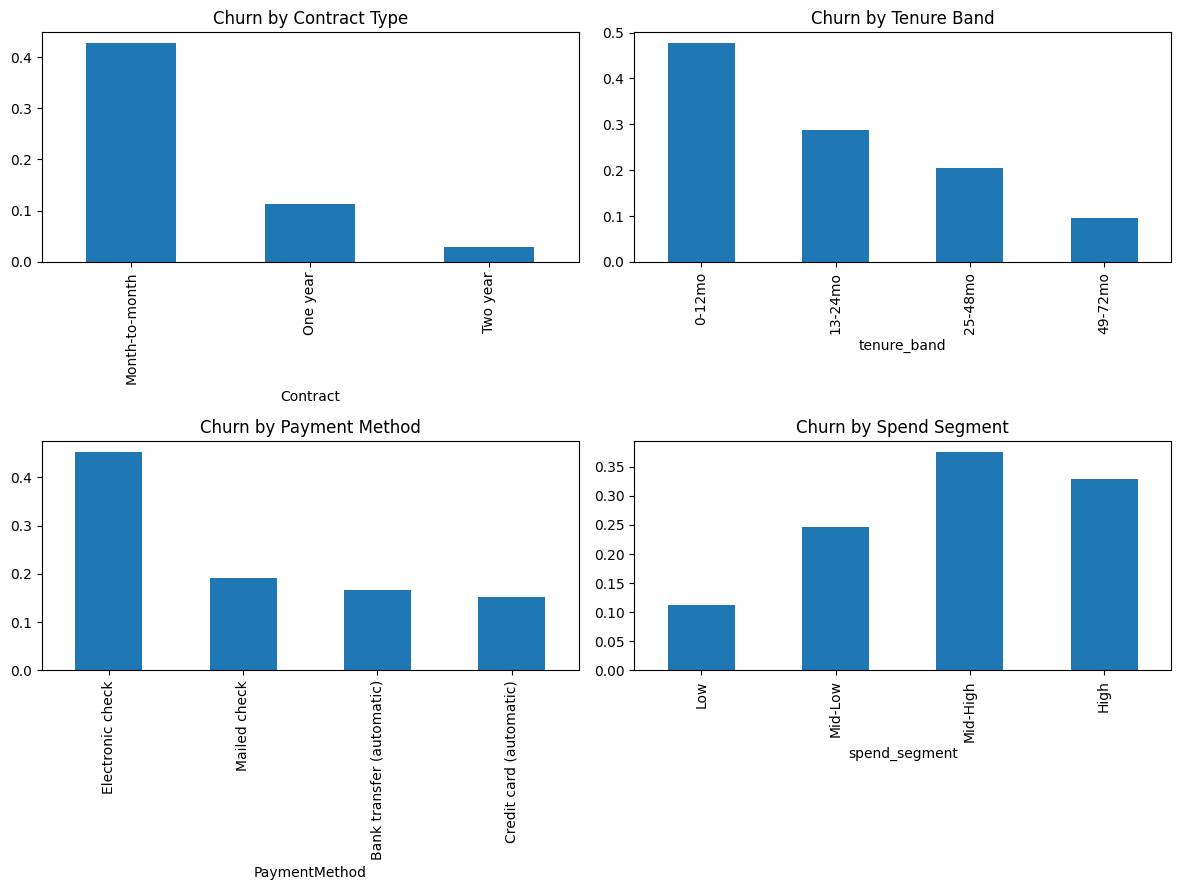

In [9]:
# 7. CHARTS
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
churn_by_contract.plot(kind='bar', ax=axes[0, 0], title='Churn by Contract Type')
churn_by_tenure.plot(kind='bar', ax=axes[0, 1], title='Churn by Tenure Band')
churn_by_payment.plot(kind='bar', ax=axes[1, 0], title='Churn by Payment Method')
churn_by_spend.plot(kind='bar', ax=axes[1, 1], title='Churn by Spend Segment')
plt.tight_layout()
plt.savefig('churn_analysis_charts.png')
plt.show()

### Step 8: Save For Power Bi

In [10]:
# 8. SAVE FOR POWER BI
df.to_csv('churn_clean.csv', index=False)
churn_by_contract.to_csv('churn_by_contract.csv')